# **Network Stock Portfolio Optimization**

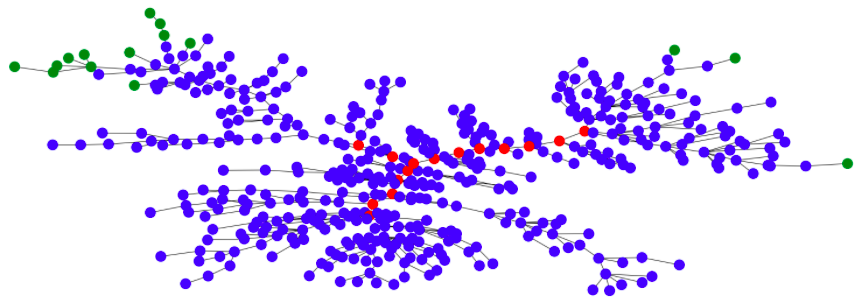

## **Context and Problem Statement**

Active investing in the asset management industry **aims to beat the stock market’s average returns**, for which portfolio managers track a particular index and try to beat that index by creating their own portfolios.

Portfolio construction involves selection of stocks that have a **higher probability of giving better returns** in comparison to the tracking index, like **S&P 500**. In this project, we will use the concept of Network Analysis to select a basket of stocks and create two portfolios. We will then simulate portfolio value by investing a certain amount, keeping the portfolio for an entire year and we will then compare it against the S&P 500 index.

In this project we will try to follow the approach mentioned in the below research paper:

**[Dynamic portfolio strategy using a clustering
approach](https://arxiv.org/pdf/1608.03058.pdf)**

## **Proposed Approach**

- Collect the price data for all S&P 500 components from 2011 till 2020
- Compute log returns for the S&P 500 components for same time period
- Compute the **correlation matrix** for the above log returns
- Find out the **Top n central and peripheral stocks** based on the following network topological parameters:
    - Degree centrality
    - Betweenness centrality
    - Distance on degree criterion
    - Distance on correlation criterion
    - Distance on distance criterion
- Simulate the performance of central and peripheral portfolios against the performance of S&P 500 for the year 2021    

## **Loading the Libraries**

We will need to first install the library - `pandas_datareader` using `!pip install pandas_datareader`

In [65]:
import tqdm
import requests
import numpy as np
import pandas as pd
import seaborn as sns
import networkx as nx
import plotly.express as px
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import yfinance as yf
import io


import warnings
warnings.filterwarnings('ignore')

## **Getting the S&P 500 Components**

Beautiful Soup is a library that makes it easy to scrape information from web pages.

https://www.crummy.com/software/BeautifulSoup/bs4/doc/

In [66]:
url = "https://es.wikipedia.org/wiki/%C3%8Dndice_de_Precios_y_Cotizaciones"

# Always include a User-Agent to avoid being blocked
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36"
}
resp = requests.get(url, headers=headers)

# Parse with BeautifulSoup
soup = BeautifulSoup(resp.text, "html.parser")

# Verify which tables are present
tables = soup.find_all("table")
print(f"Found {len(tables)} tables on the page")

# The S&P 500 table is usually the first one
table = tables[1]

# CORRECCIÓN: Se usa io.StringIO para que Pandas lea el string HTML correctamente
# y no intente buscar un archivo en el disco duro.
df = pd.read_html(io.StringIO(str(table)))[0]

# Extract tickers
tickers_raw = (
    df["Símbolo"]
    .astype(str)
    .str.replace("[3]", "", regex=False)
    .str.strip()
    .dropna()
    .tolist()
)

# 
tickers = []
for ticker in tickers_raw:
    components = ticker.split(' ')
    ticker_1 = ''.join(components)
    ticker_2 = components[0]
    ticker_3 = components[0] + '.MX'
    ticker_4 = ''.join(components) + '.MX'
    new_tickers = [ticker_1, ticker_2, ticker_3, ticker_4]
    tickers.extend(new_tickers)


print(f"Extracted {len(tickers)} tickers.")
print(tickers[:10])

Found 4 tables on the page
Extracted 144 tickers.
['AMXL', 'AMX', 'AMX.MX', 'AMXL.MX', 'WALMEXV', 'WALMEX', 'WALMEX.MX', 'WALMEXV.MX', 'FEMSAUBD', 'FEMSA']


## **Getting the Price Data for all the S&P 500 components in the last 10 years**

In [67]:
stock_data = yf.download(tickers, start='2011-01-01', end='2020-12-31', group_by='ticker', auto_adjust=True)
stock_data.head()

$COMPARC.MX: possibly delisted; no price data found  (1d 2011-01-01 -> 2020-12-31)
[**                     4%                       ]  5 of 118 completed$AMX.MX: possibly delisted; no timezone found
[**                     5%                       ]  6 of 118 completed$ASURB: possibly delisted; no timezone found
[***                    6%                       ]  7 of 118 completed$ALPEK.MX: possibly delisted; no timezone found
$LALA.MX: possibly delisted; no timezone found
[***                    7%                       ]  8 of 118 completed$ALFAA: possibly delisted; no timezone found
$ASUR.MX: possibly delisted; no timezone found
[****                   8%                       ]  9 of 118 completed$IENOVA: possibly delisted; no timezone found
[****                   9%                       ]  11 of 118 completed$ALFAA.MX: possibly delisted; no timezone found
[*****                 10%                       ]  12 of 118 completed$GMEXICO.MX: possibly delisted; no timezone found
[**

Ticker     COMPARC.MX                                 GFINBURO.MX             \
Price            Open High Low Close Adj Close Volume        Open       High   
Date                                                                           
2011-01-03        NaN  NaN NaN   NaN       NaN    NaN   20.919640  21.374585   
2011-01-04        NaN  NaN NaN   NaN       NaN    NaN   21.272614  21.335365   
2011-01-05        NaN  NaN NaN   NaN       NaN    NaN   21.276539  21.354978   
2011-01-06        NaN  NaN NaN   NaN       NaN    NaN   20.903952  21.370664   
2011-01-07        NaN  NaN NaN   NaN       NaN    NaN   21.245161  21.296147   

Ticker                            ... ICH                        ELEKTRA.MX  \
Price             Low      Close  ... Low Close Adj Close Volume       Open   
Date                              ...                                         
2011-01-03  20.868654  20.919640  ... NaN   NaN       NaN    NaN        NaN   
2011-01-04  20.907873  21.272614  ... NaN   NaN       NaN    NaN        NaN   
2011-01-05  21.021612  21.276539  ... NaN   NaN       NaN    NaN        NaN   
2011-01-06  20.864733  20.903952  ... NaN   NaN       NaN    NaN        NaN   
2011-01-07  20.801983  21.245161  ... NaN   NaN       NaN    NaN        NaN   

Ticker                                      
Price      High Low Close Adj Close Volume  
Date                                        
2011-01-03  NaN NaN   NaN       NaN    NaN  
2011-01-04  NaN NaN   NaN       NaN    NaN  
2011-01-05  NaN NaN   NaN       NaN    NaN  
2011-01-06  NaN NaN   NaN       NaN    NaN  
2011-01-07  NaN NaN   NaN       NaN    NaN  

[5 rows x 677 columns]

In [68]:
# Filter the dataset to just close price
price_data = stock_data.xs(key="Close", axis=1, level="Price")
price_data = price_data.dropna(axis=1, how='all')

In [69]:
price_data.head()

Ticker,GFINBURO.MX,ALFA.MX,GCARSOA1.MX,BOLSAA.MX,FEMSAUBD.MX,WALMEX.MX,AC.MX,GAPB.MX,KOF,CEMEXCPO.MX,...,LABB.MX,ICA,ALSEA.MX,AZTECACPO.MX,GFNORTEO.MX,ALPEKA.MX,GRUMAB.MX,ICHB.MX,ALFA,GMEXICOB.MX
Date,,,,,,,,,,,,,,,,,,,,,
2011-01-03,20.919640,NaN,30.194279,12.532255,47.989162,21.720970,32.839378,25.535770,53.162075,9.788302,...,23.586142,NaN,11.285215,7.957045,29.735302,NaN,18.878252,46.647148,NaN,27.747822
2011-01-04,21.272614,NaN,29.969700,12.484165,48.079128,21.745729,33.184155,25.535770,52.297745,9.744571,...,23.640991,NaN,11.276556,7.892277,30.086084,NaN,18.682028,46.110970,NaN,27.272621
2011-01-05,21.276539,NaN,30.205900,12.551493,47.836903,22.086178,34.046078,26.006779,52.602791,9.729993,...,24.283539,NaN,11.285215,7.827513,30.477551,NaN,18.804665,46.963104,NaN,27.228914
2011-01-06,20.903952,NaN,27.054346,12.551493,47.539291,22.135696,33.620506,25.794064,52.755322,9.518630,...,24.526453,NaN,11.293877,7.651717,30.396198,NaN,18.698380,47.116299,NaN,26.983124
2011-01-07,21.245161,NaN,28.044331,12.253334,46.999481,22.197598,33.701305,25.753544,52.596458,9.598804,...,24.722351,NaN,11.276556,7.512931,30.253849,NaN,18.567562,46.781189,NaN,27.048656


## **Missing Data due to Index Rebalancing**

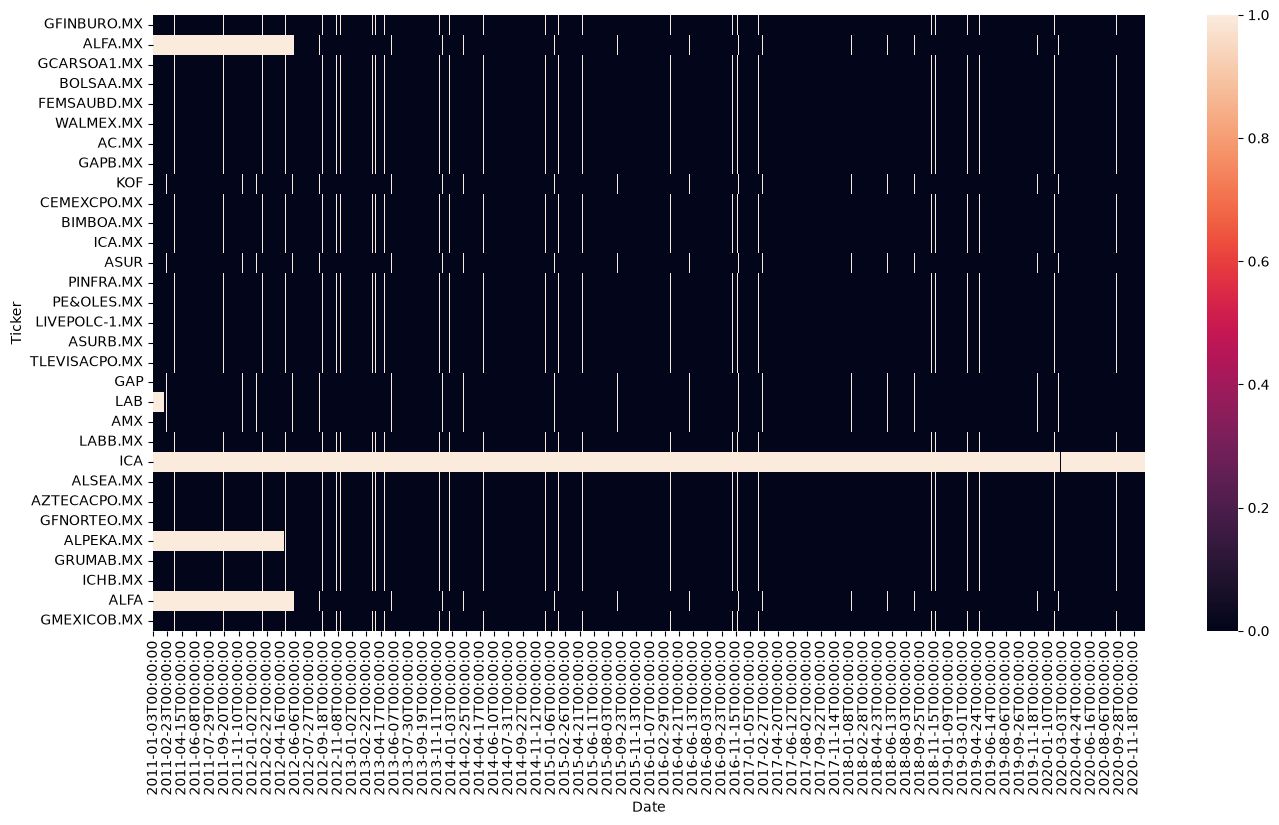

In [70]:
figure = plt.figure(figsize=(16, 8))
sns.heatmap(price_data.T.isnull());

The missing data is due to the fact that **certain stocks may move out of the S&P 500** and **certain stocks may enter the S&P 500** in this respective timeframe.

In [71]:
price_data_cleaned = price_data.drop(['ICA', 'ICA.MX', 'ALFA', 'ALFA.MX', 'ALPEKA.MX'], axis=1) # dropping na values columnwise
price_data_cleaned = price_data_cleaned.interpolate(method='time', limit_direction='both')

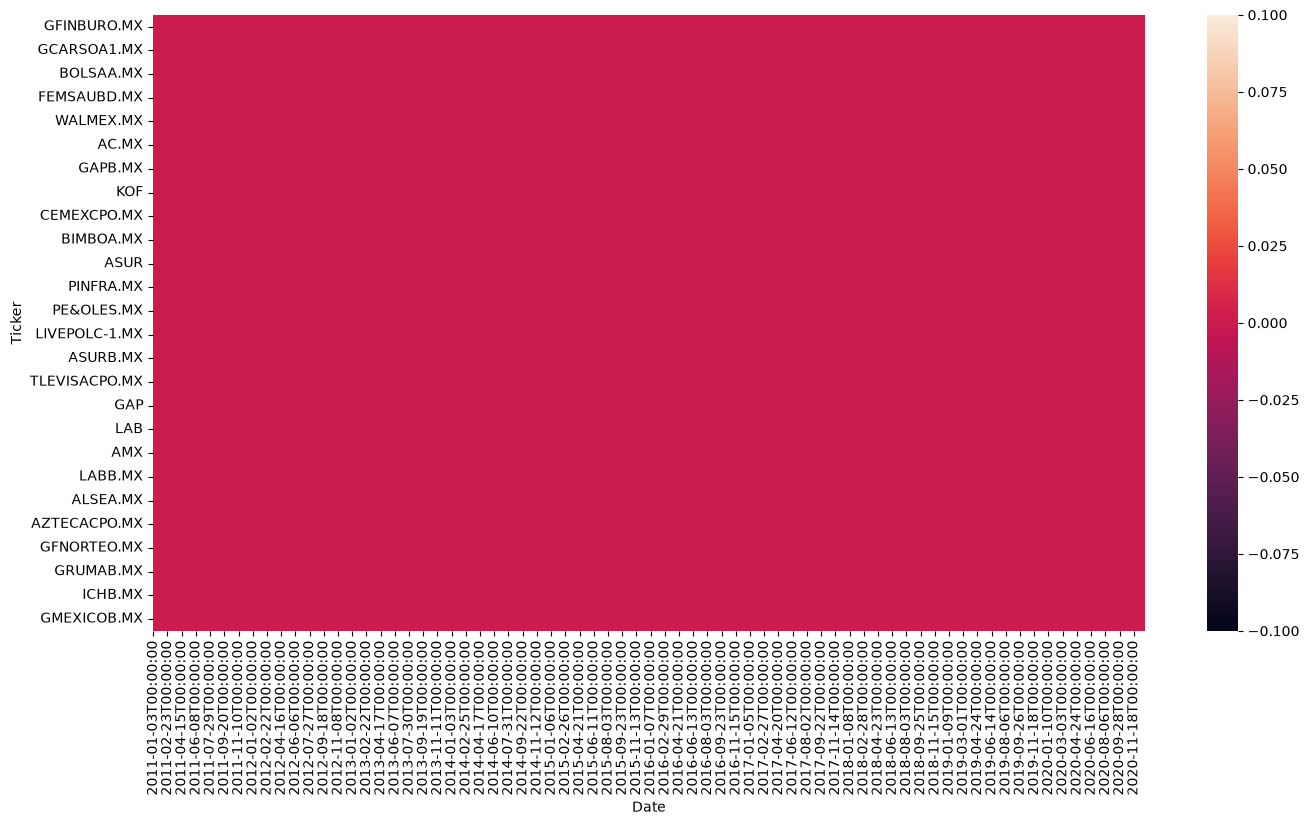

In [72]:
figure = plt.figure(figsize=(16, 8))
sns.heatmap(price_data_cleaned.T.isnull());

The null values are removed - the data is clean and the plot also helps in finding that there are no missing values.

## **Getting Yearwise Data**

In [73]:
def get_year_wise_snp_500_data(data, year):
    year_wise_data = data.loc['{}-01-01'.format(year):'{}-12-31'.format(year)]

    return year_wise_data

In [74]:
# Getting year wise data of S&P stocks from 2011 to 2020
snp_500_2011 = get_year_wise_snp_500_data(price_data_cleaned, 2011)
snp_500_2012 = get_year_wise_snp_500_data(price_data_cleaned, 2012)
snp_500_2013 = get_year_wise_snp_500_data(price_data_cleaned, 2013)
snp_500_2014 = get_year_wise_snp_500_data(price_data_cleaned, 2014)
snp_500_2015 = get_year_wise_snp_500_data(price_data_cleaned, 2015)
snp_500_2016 = get_year_wise_snp_500_data(price_data_cleaned, 2016)
snp_500_2017 = get_year_wise_snp_500_data(price_data_cleaned, 2017)
snp_500_2018 = get_year_wise_snp_500_data(price_data_cleaned, 2018)
snp_500_2019 = get_year_wise_snp_500_data(price_data_cleaned, 2019)
snp_500_2020 = get_year_wise_snp_500_data(price_data_cleaned, 2020)

In [75]:
snp_500_2011

Ticker,GFINBURO.MX,GCARSOA1.MX,BOLSAA.MX,FEMSAUBD.MX,WALMEX.MX,AC.MX,GAPB.MX,KOF,CEMEXCPO.MX,BIMBOA.MX,...,GAP,LAB,AMX,LABB.MX,ALSEA.MX,AZTECACPO.MX,GFNORTEO.MX,GRUMAB.MX,ICHB.MX,GMEXICOB.MX
Date,,,,,,,,,,,,,,,,,,,,,
2011-01-03,20.919640,30.194279,12.532255,47.989162,21.720970,32.839378,25.535770,53.162075,9.788302,21.863720,...,13.931393,14.0200,20.474091,23.586142,11.285215,7.957045,29.735302,18.878252,46.647148,27.747822
2011-01-04,21.272614,29.969700,12.484165,48.079128,21.745729,33.184155,25.535770,52.297745,9.744571,21.994753,...,13.768377,14.0200,20.527088,23.640991,11.276556,7.892277,30.086084,18.682028,46.110970,27.272621
2011-01-05,21.276539,30.205900,12.551493,47.836903,22.086178,34.046078,26.006779,52.602791,9.729993,22.495644,...,13.937660,14.0200,20.802664,24.283539,11.285215,7.827513,30.477551,18.804665,46.963104,27.228914
2011-01-06,20.903952,27.054346,12.551493,47.539291,22.135696,33.620506,25.794064,52.755322,9.518630,22.364611,...,12.978387,14.0200,20.781467,24.526453,11.293877,7.651717,30.396198,18.698380,47.116299,26.983124
2011-01-07,21.245161,28.044331,12.253334,46.999481,22.197598,33.701305,25.753544,52.596458,9.598804,22.375177,...,12.859257,14.0200,20.845057,24.722351,11.276556,7.512931,30.253849,18.567562,46.781189,27.048656
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2011-12-26,20.053047,26.875385,11.687526,67.206245,23.685474,39.240303,25.126291,62.930017,5.753160,23.673296,...,12.093411,13.5225,16.118016,21.517454,12.074122,8.289611,22.239532,21.617197,43.717339,21.679319
2011-12-27,20.520685,26.851309,11.387845,68.705177,23.672905,39.023140,25.258116,62.882816,5.647041,23.783800,...,12.165215,13.5500,16.075150,21.219692,11.915945,8.354447,22.085449,21.347389,44.090744,21.047878
2011-12-28,20.290831,26.466234,11.228015,67.241425,23.647753,38.825722,24.778263,62.218845,5.540922,23.256781,...,12.063098,13.4100,15.875099,20.671175,11.608381,8.252563,21.982727,21.118465,43.985424,20.837399


In [76]:
snp_500_2011.shift(1)

Ticker,GFINBURO.MX,GCARSOA1.MX,BOLSAA.MX,FEMSAUBD.MX,WALMEX.MX,AC.MX,GAPB.MX,KOF,CEMEXCPO.MX,BIMBOA.MX,...,GAP,LAB,AMX,LABB.MX,ALSEA.MX,AZTECACPO.MX,GFNORTEO.MX,GRUMAB.MX,ICHB.MX,GMEXICOB.MX
Date,,,,,,,,,,,,,,,,,,,,,
2011-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-04,20.919640,30.194279,12.532255,47.989162,21.720970,32.839378,25.535770,53.162075,9.788302,21.863720,...,13.931393,14.0200,20.474091,23.586142,11.285215,7.957045,29.735302,18.878252,46.647148,27.747822
2011-01-05,21.272614,29.969700,12.484165,48.079128,21.745729,33.184155,25.535770,52.297745,9.744571,21.994753,...,13.768377,14.0200,20.527088,23.640991,11.276556,7.892277,30.086084,18.682028,46.110970,27.272621
2011-01-06,21.276539,30.205900,12.551493,47.836903,22.086178,34.046078,26.006779,52.602791,9.729993,22.495644,...,13.937660,14.0200,20.802664,24.283539,11.285215,7.827513,30.477551,18.804665,46.963104,27.228914
2011-01-07,20.903952,27.054346,12.551493,47.539291,22.135696,33.620506,25.794064,52.755322,9.518630,22.364611,...,12.978387,14.0200,20.781467,24.526453,11.293877,7.651717,30.396198,18.698380,47.116299,26.983124
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2011-12-26,20.092680,26.851309,11.637578,68.043709,23.515715,38.819149,25.152649,63.071621,5.684940,23.792299,...,11.878002,13.4400,16.246614,21.470442,11.652318,8.196987,22.414162,21.420969,43.372654,21.673628
2011-12-27,20.053047,26.875385,11.687526,67.206245,23.685474,39.240303,25.126291,62.930017,5.753160,23.673296,...,12.093411,13.5225,16.118016,21.517454,12.074122,8.289611,22.239532,21.617197,43.717339,21.679319
2011-12-28,20.520685,26.851309,11.387845,68.705177,23.672905,39.023140,25.258116,62.882816,5.647041,23.783800,...,12.165215,13.5500,16.075150,21.219692,11.915945,8.354447,22.085449,21.347389,44.090744,21.047878


## **Computing the Daily Log Returns**

Statistically, **simple stock returns are always assumed to follow a Log Normal distribution**. It is therefore plausible to use properties of the Normal distribution in statistical estimation for Log returns, but not for the simple returns.

Stock Returns analysis is a time series analysis, in which you also take care of stationarity which is normally obtained from Log returns but not from simple returns.

In [77]:
# Calculating daily log returns by subtracting between two days with the help of shift function
log_returns_2011 = np.log(snp_500_2011.shift(1)) - np.log(snp_500_2011)
log_returns_2012 = np.log(snp_500_2012.shift(1)) - np.log(snp_500_2012)
log_returns_2013 = np.log(snp_500_2013.shift(1)) - np.log(snp_500_2013)
log_returns_2014 = np.log(snp_500_2014.shift(1)) - np.log(snp_500_2014)
log_returns_2015 = np.log(snp_500_2015.shift(1)) - np.log(snp_500_2015)
log_returns_2016 = np.log(snp_500_2016.shift(1)) - np.log(snp_500_2016)
log_returns_2017 = np.log(snp_500_2017.shift(1)) - np.log(snp_500_2017)
log_returns_2018 = np.log(snp_500_2018.shift(1)) - np.log(snp_500_2018)
log_returns_2019 = np.log(snp_500_2019.shift(1)) - np.log(snp_500_2019)
log_returns_2020 = np.log(snp_500_2020.shift(1)) - np.log(snp_500_2020)

## **Computing the Correlation of Returns**

In [78]:
# Computing adjacency matrix:
return_correlation_2011 = log_returns_2011.corr()
return_correlation_2012 = log_returns_2012.corr()
return_correlation_2013 = log_returns_2013.corr()
return_correlation_2014 = log_returns_2014.corr()
return_correlation_2015 = log_returns_2015.corr()
return_correlation_2016 = log_returns_2016.corr()
return_correlation_2017 = log_returns_2017.corr()
return_correlation_2018 = log_returns_2018.corr()
return_correlation_2019 = log_returns_2019.corr()
return_correlation_2020 = log_returns_2020.corr()

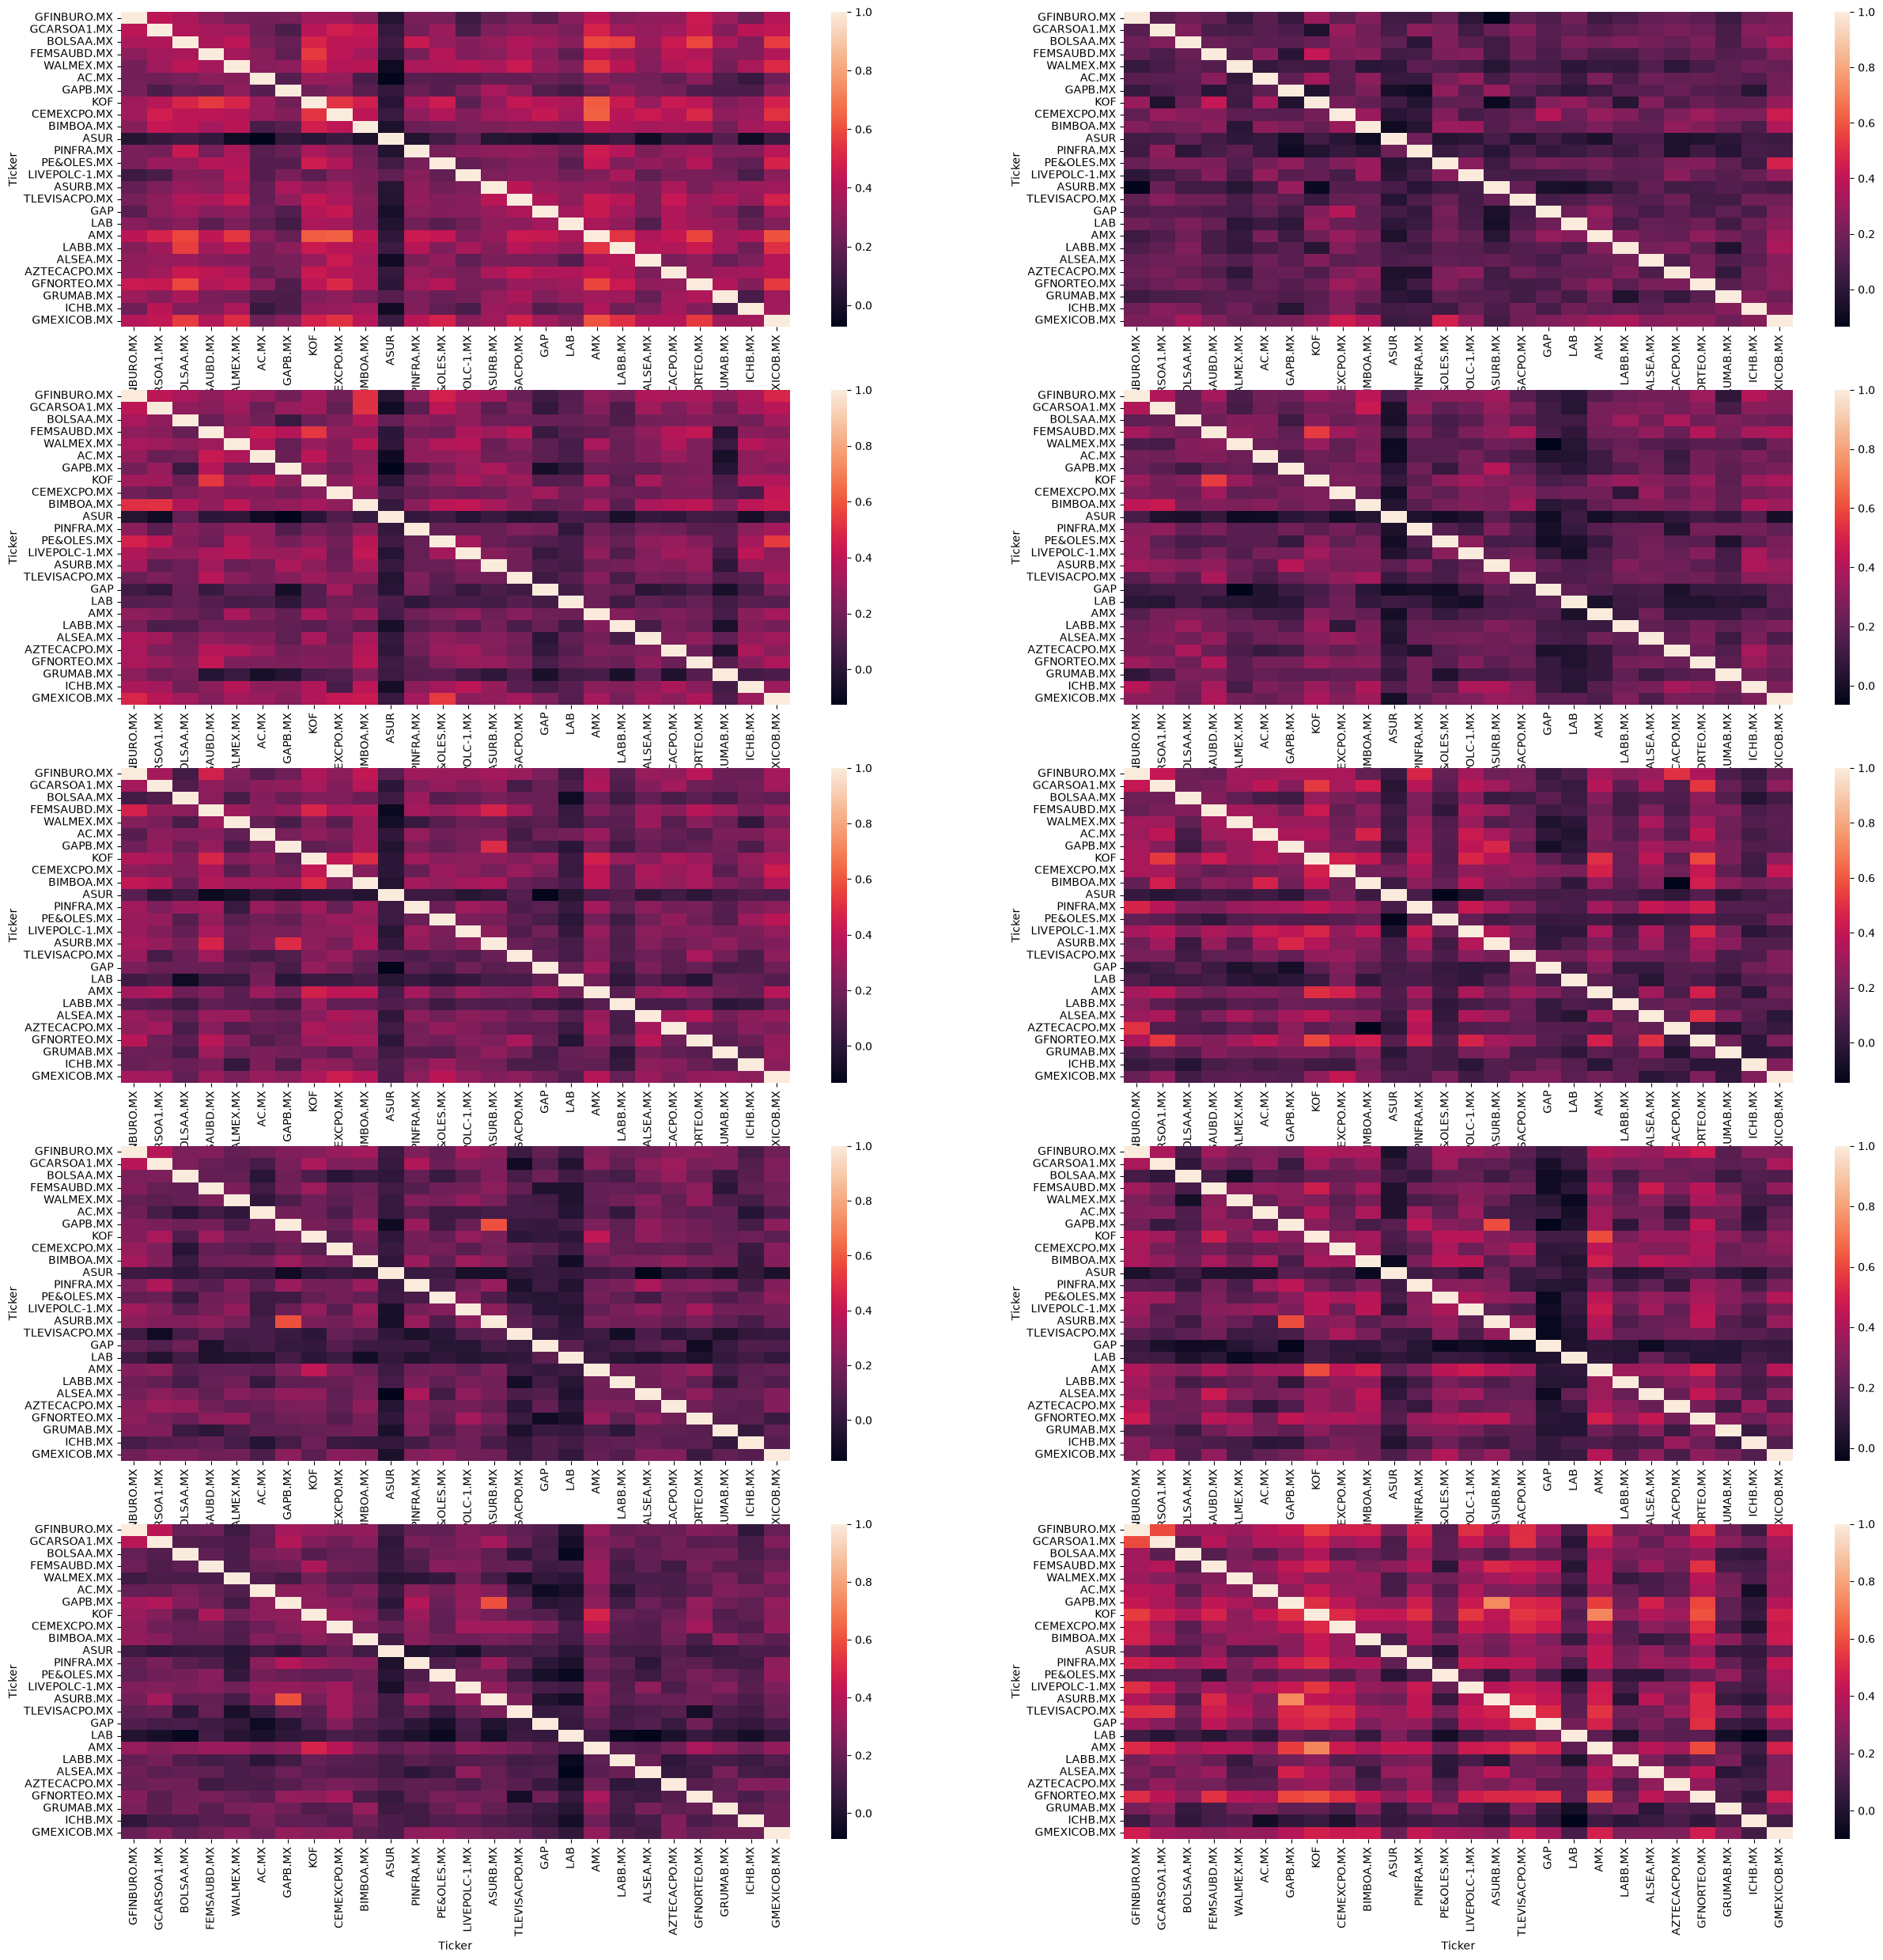

In [79]:
figure, axes = plt.subplots(5, 2, figsize=(30, 30))
sns.heatmap(return_correlation_2011, ax=axes[0, 0]);
sns.heatmap(return_correlation_2012, ax=axes[0, 1]);
sns.heatmap(return_correlation_2013, ax=axes[1, 0]);
sns.heatmap(return_correlation_2014, ax=axes[1, 1]);
sns.heatmap(return_correlation_2015, ax=axes[2, 0]);
sns.heatmap(return_correlation_2016, ax=axes[2, 1]);
sns.heatmap(return_correlation_2017, ax=axes[3, 0]);
sns.heatmap(return_correlation_2018, ax=axes[3, 1]);
sns.heatmap(return_correlation_2019, ax=axes[4, 0]);
sns.heatmap(return_correlation_2020, ax=axes[4, 1]);

## **Inferences**

The first plot for the year 2011 shows that there is high correlation among the stocks. It shows that since in 2011 there was a market crash and there was volatility in the market, the prices of the stock went down along with the other stocks and this is the reason for high correlation.

Similarly in 2012, 2014 and 2017 the market is kind of stable, and hence the correlation among stocks is low.

In 2020, due to the COVID pandemic and the volatility in the market, the prices of the stock went down or up along with other stocks, and this is the reason for high correlation.

From this we can infer that, **In stable market conditions, correlation matrices have low correlation values whereas in critical market conditions, correlation matrices have high correlation values.**

## **Creating Graphs**

In [80]:
graph_2011 = nx.Graph(return_correlation_2011)

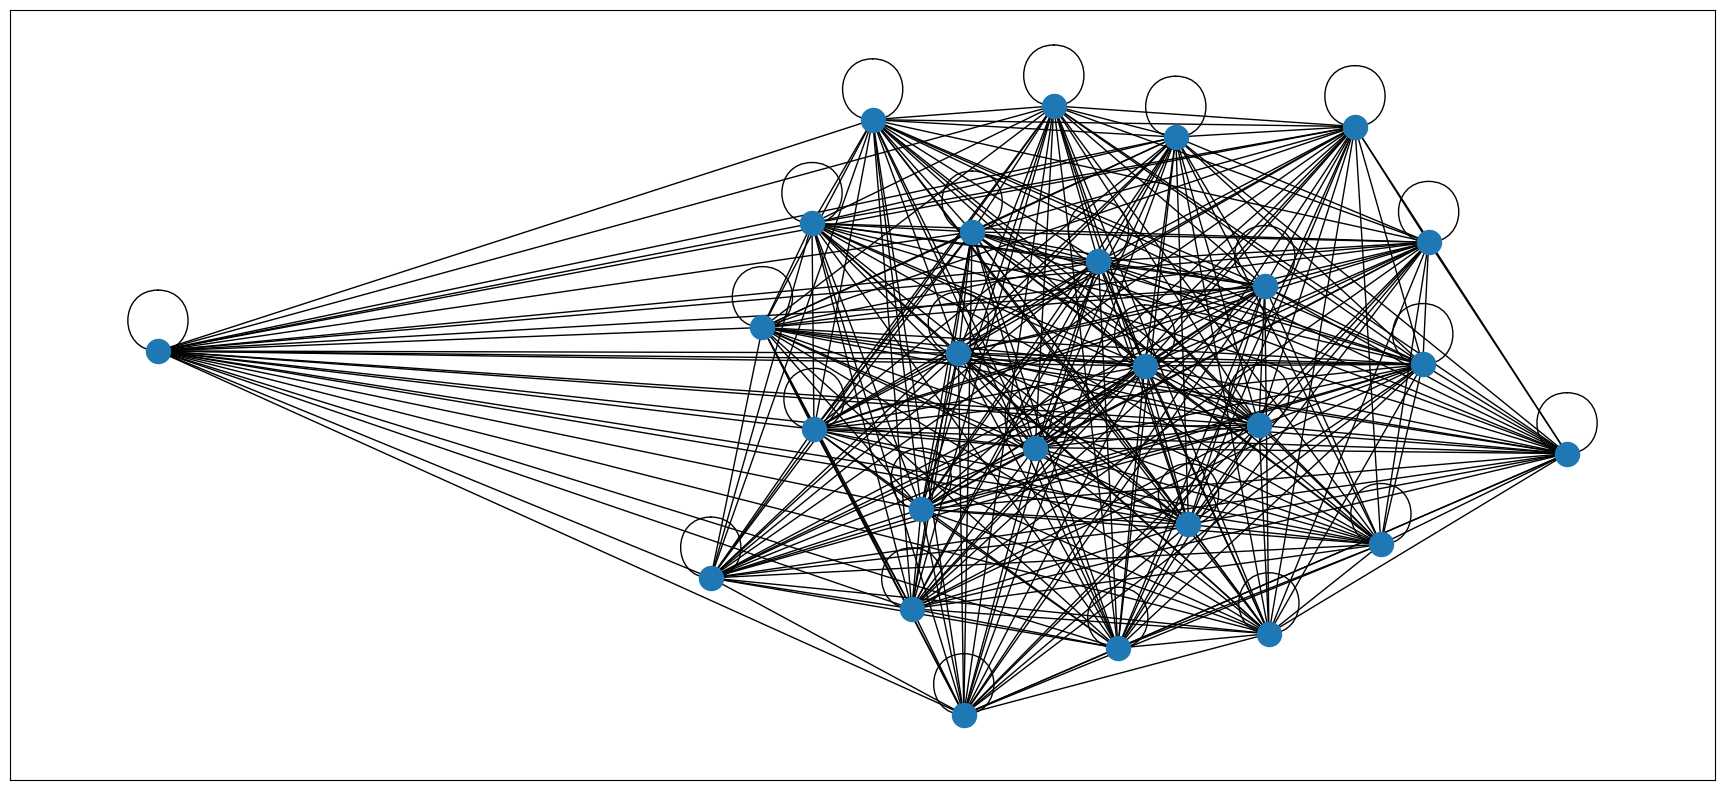

In [81]:
figure = plt.figure(figsize=(22, 10))
nx.draw_networkx(graph_2011, with_labels=False)

This is a **fully connected network** as we created it using the correlation matrix.

A fully connected network means every variable has connections with all the other variables in the network and will also have self-loops.

## **Filtering Graphs using MST**

**MST - Minimum Spanning Tree**

A minimum spanning tree (MST) or minimum weight spanning tree is a subset of the edges of a connected, edge-weighted undirected graph that connects all the vertices together, without any cycles and with the minimum possible total edge weight.That is, it is a spanning tree whose sum of edge weights is as small as possible.

**MST** is one of the popular techniques to eliminate the redundancies and noise and meanwhile maintain the significant links in the network.

While removing redundancy and noise in the data using MST, we might lose some information as well.

You can find more on MST [here](https://visualgo.net/en/mst)

In [82]:
distance_2011 = np.sqrt(2 * (1 - return_correlation_2011))
distance_2012 = np.sqrt(2 * (1 - return_correlation_2012))
distance_2013 = np.sqrt(2 * (1 - return_correlation_2013))
distance_2014 = np.sqrt(2 * (1 - return_correlation_2014))
distance_2015 = np.sqrt(2 * (1 - return_correlation_2015))
distance_2016 = np.sqrt(2 * (1 - return_correlation_2016))
distance_2017 = np.sqrt(2 * (1 - return_correlation_2017))
distance_2018 = np.sqrt(2 * (1 - return_correlation_2018))
distance_2019 = np.sqrt(2 * (1 - return_correlation_2019))
distance_2020 = np.sqrt(2 * (1 - return_correlation_2020))

Before the construction of the MST graph, **the correlation coefficient is converted into a distance.**

In [83]:
distance_2011_graph = nx.Graph(distance_2011)
distance_2012_graph = nx.Graph(distance_2012)
distance_2013_graph = nx.Graph(distance_2013)
distance_2014_graph = nx.Graph(distance_2014)
distance_2015_graph = nx.Graph(distance_2015)
distance_2016_graph = nx.Graph(distance_2016)
distance_2017_graph = nx.Graph(distance_2017)
distance_2018_graph = nx.Graph(distance_2018)
distance_2019_graph = nx.Graph(distance_2019)
distance_2020_graph = nx.Graph(distance_2020)

In [84]:
graph_2011_filtered = nx.minimum_spanning_tree(distance_2011_graph)
graph_2012_filtered = nx.minimum_spanning_tree(distance_2012_graph)
graph_2013_filtered = nx.minimum_spanning_tree(distance_2013_graph)
graph_2014_filtered = nx.minimum_spanning_tree(distance_2014_graph)
graph_2015_filtered = nx.minimum_spanning_tree(distance_2015_graph)
graph_2016_filtered = nx.minimum_spanning_tree(distance_2016_graph)
graph_2017_filtered = nx.minimum_spanning_tree(distance_2017_graph)
graph_2018_filtered = nx.minimum_spanning_tree(distance_2018_graph)
graph_2019_filtered = nx.minimum_spanning_tree(distance_2019_graph)
graph_2020_filtered = nx.minimum_spanning_tree(distance_2020_graph)

We choose the MST method to filter out the network graph in each window so as to eliminate the redundancies and noise, and still maintain significant links.

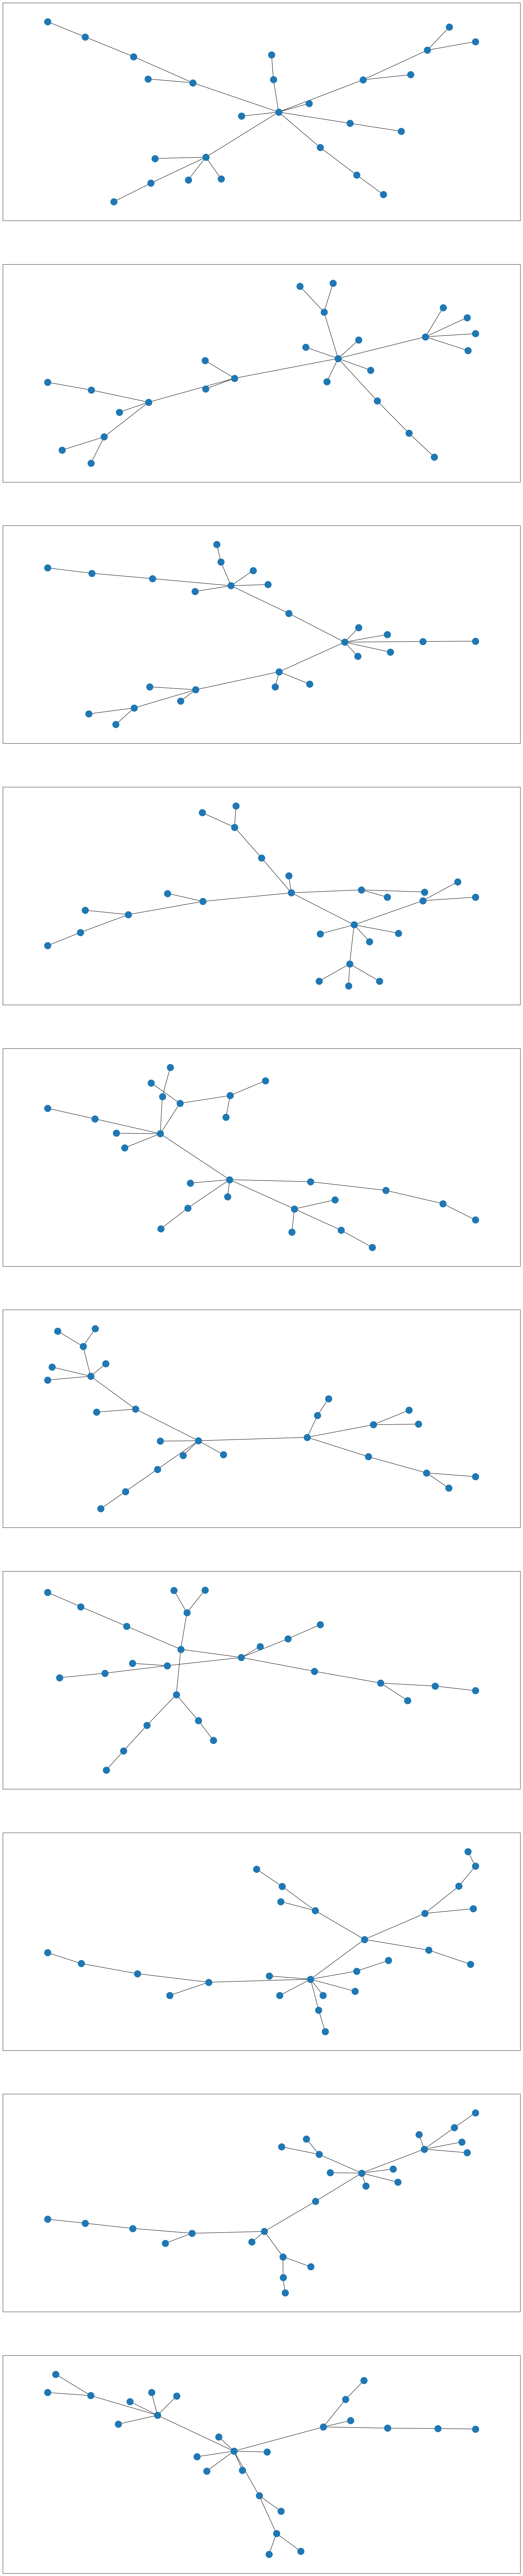

In [85]:
figure, axes = plt.subplots(10, 1, figsize=(24, 120))
nx.draw_networkx(graph_2011_filtered, with_labels=False, ax=axes[0])
nx.draw_networkx(graph_2012_filtered, with_labels=False, ax=axes[1])
nx.draw_networkx(graph_2013_filtered, with_labels=False, ax=axes[2])
nx.draw_networkx(graph_2014_filtered, with_labels=False, ax=axes[3])
nx.draw_networkx(graph_2015_filtered, with_labels=False, ax=axes[4])
nx.draw_networkx(graph_2016_filtered, with_labels=False, ax=axes[5])
nx.draw_networkx(graph_2017_filtered, with_labels=False, ax=axes[6])
nx.draw_networkx(graph_2018_filtered, with_labels=False, ax=axes[7])
nx.draw_networkx(graph_2019_filtered, with_labels=False, ax=axes[8])
nx.draw_networkx(graph_2020_filtered, with_labels=False, ax=axes[9])

On plotting the graphs, we see that the network looks different every year, and no two yearwise graphs look very similar.

## **Computing Graph Statistics over Time**

In [86]:
average_degree_connectivity = []
average_shortest_path_length = []
year = [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]

for graph in [graph_2011_filtered, graph_2012_filtered, graph_2013_filtered, graph_2014_filtered, graph_2015_filtered,
             graph_2016_filtered, graph_2017_filtered, graph_2018_filtered, graph_2019_filtered, graph_2020_filtered]:
    average_shortest_path_length.append(nx.average_shortest_path_length(graph))

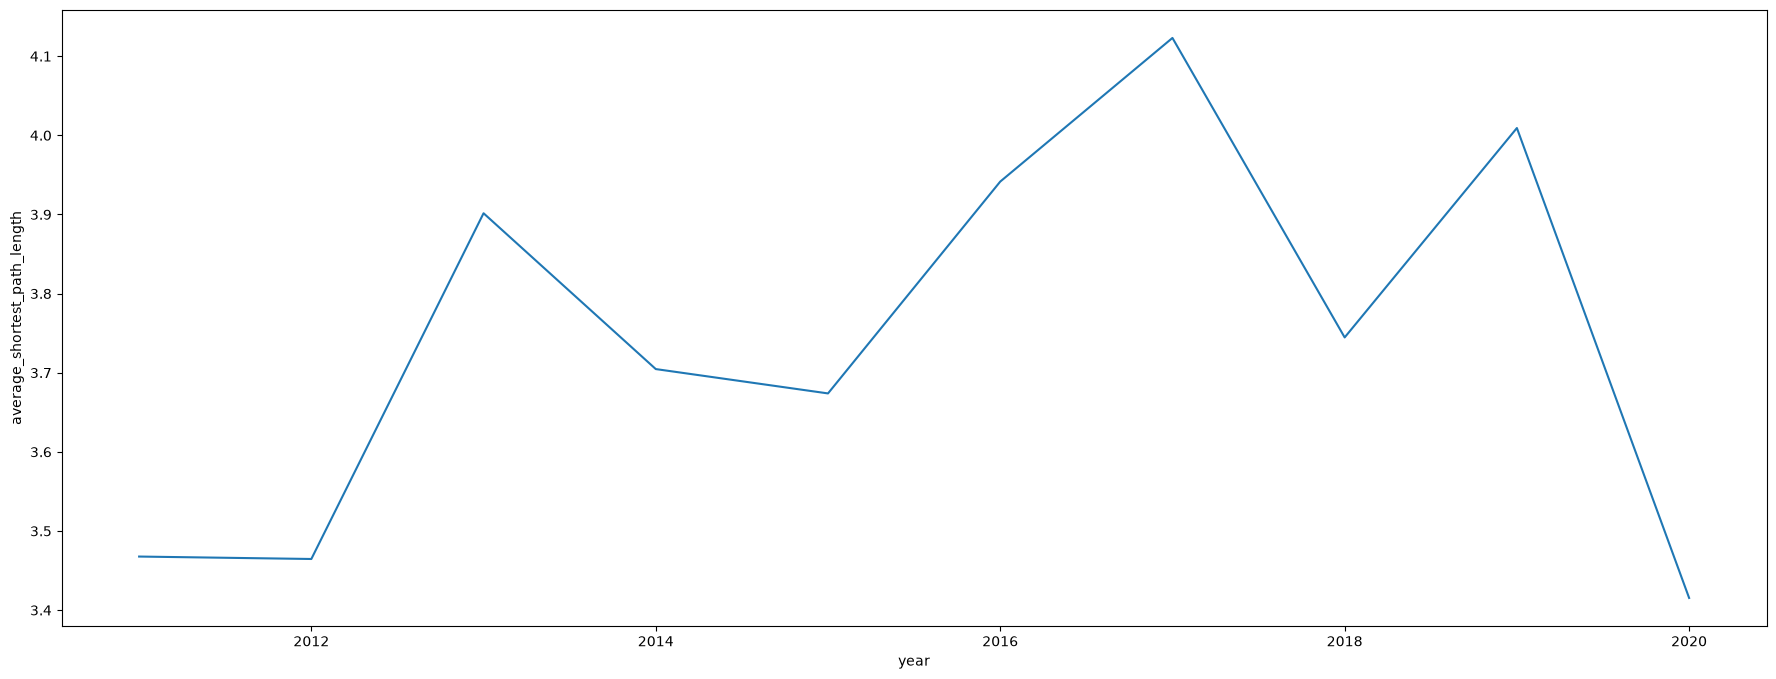

In [87]:
figure = plt.figure(figsize=(22, 8))
sns.lineplot(x='year', y='average_shortest_path_length',
             data=pd.DataFrame({'year': year, 'average_shortest_path_length': average_shortest_path_length}));

From the above plot we can see that the shortest path length was more stable till 2015 but there was significant increment in 2016 and 2017 and again there was a decrement in 2018. In 2020 there an increment again. May be this has some correlation with the financial queries.

## **Portfolio Construction**

In [88]:
log_returns_2011_till_2020 = np.log(price_data_cleaned.shift(1)) - np.log(price_data_cleaned)
return_correlation_2011_till_2020 = log_returns_2011_till_2020.corr()

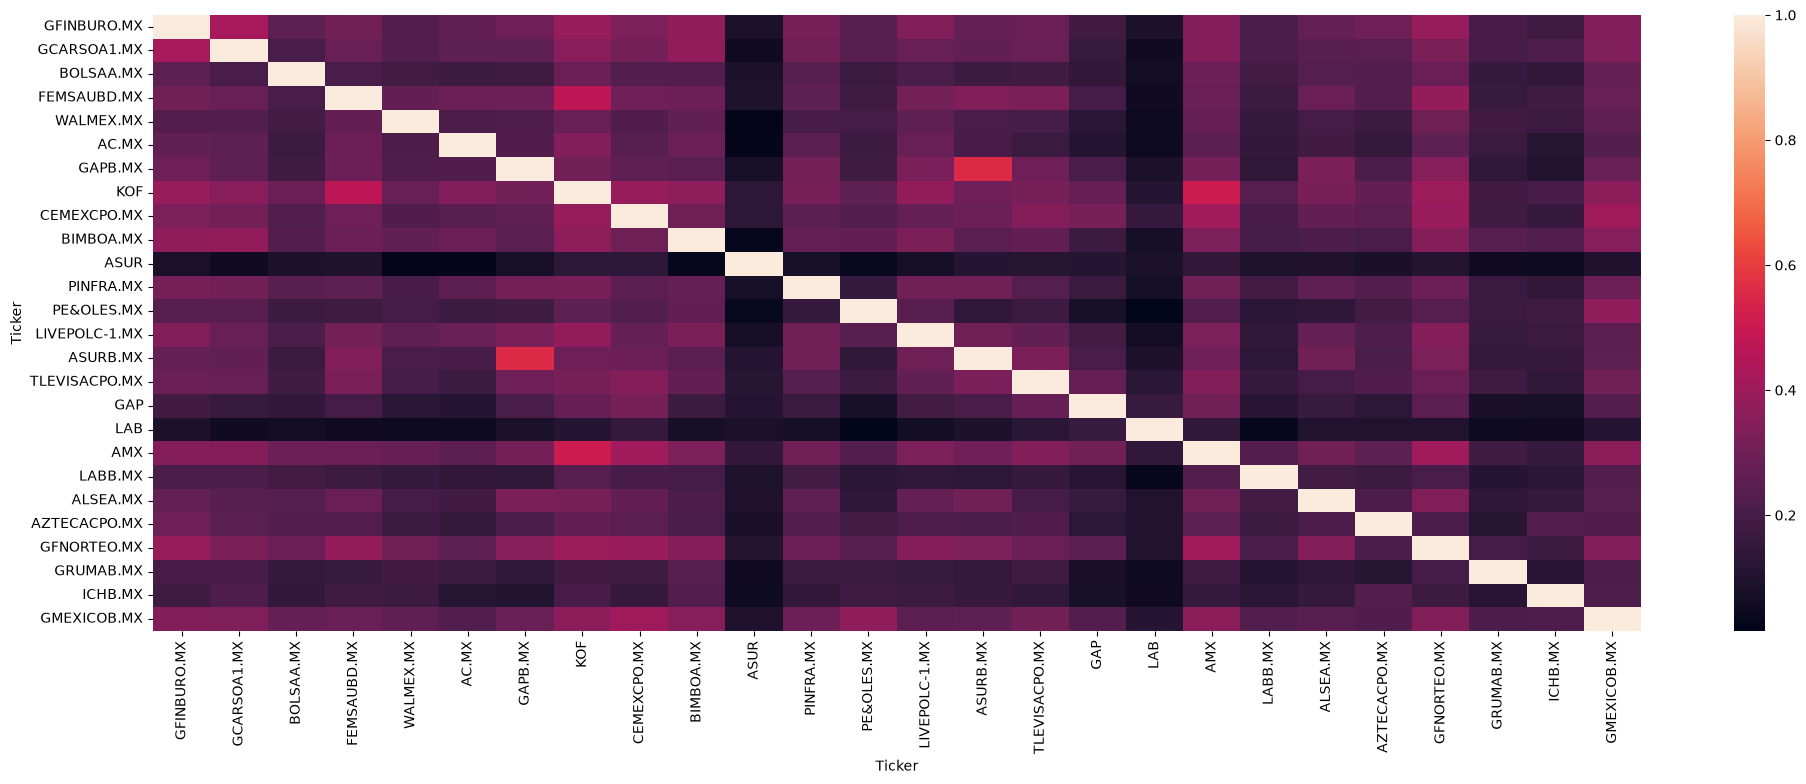

In [89]:
figure = plt.figure(figsize=(24, 8))
sns.heatmap(return_correlation_2011_till_2020);

In [90]:
distance_2011_till_2020 = np.sqrt(2 * (1 - return_correlation_2011_till_2020))
distance_2011_till_2020_graph = nx.Graph(distance_2011_till_2020)
distance_2011_till_2020_graph_filtered = nx.minimum_spanning_tree(distance_2011_till_2020_graph)

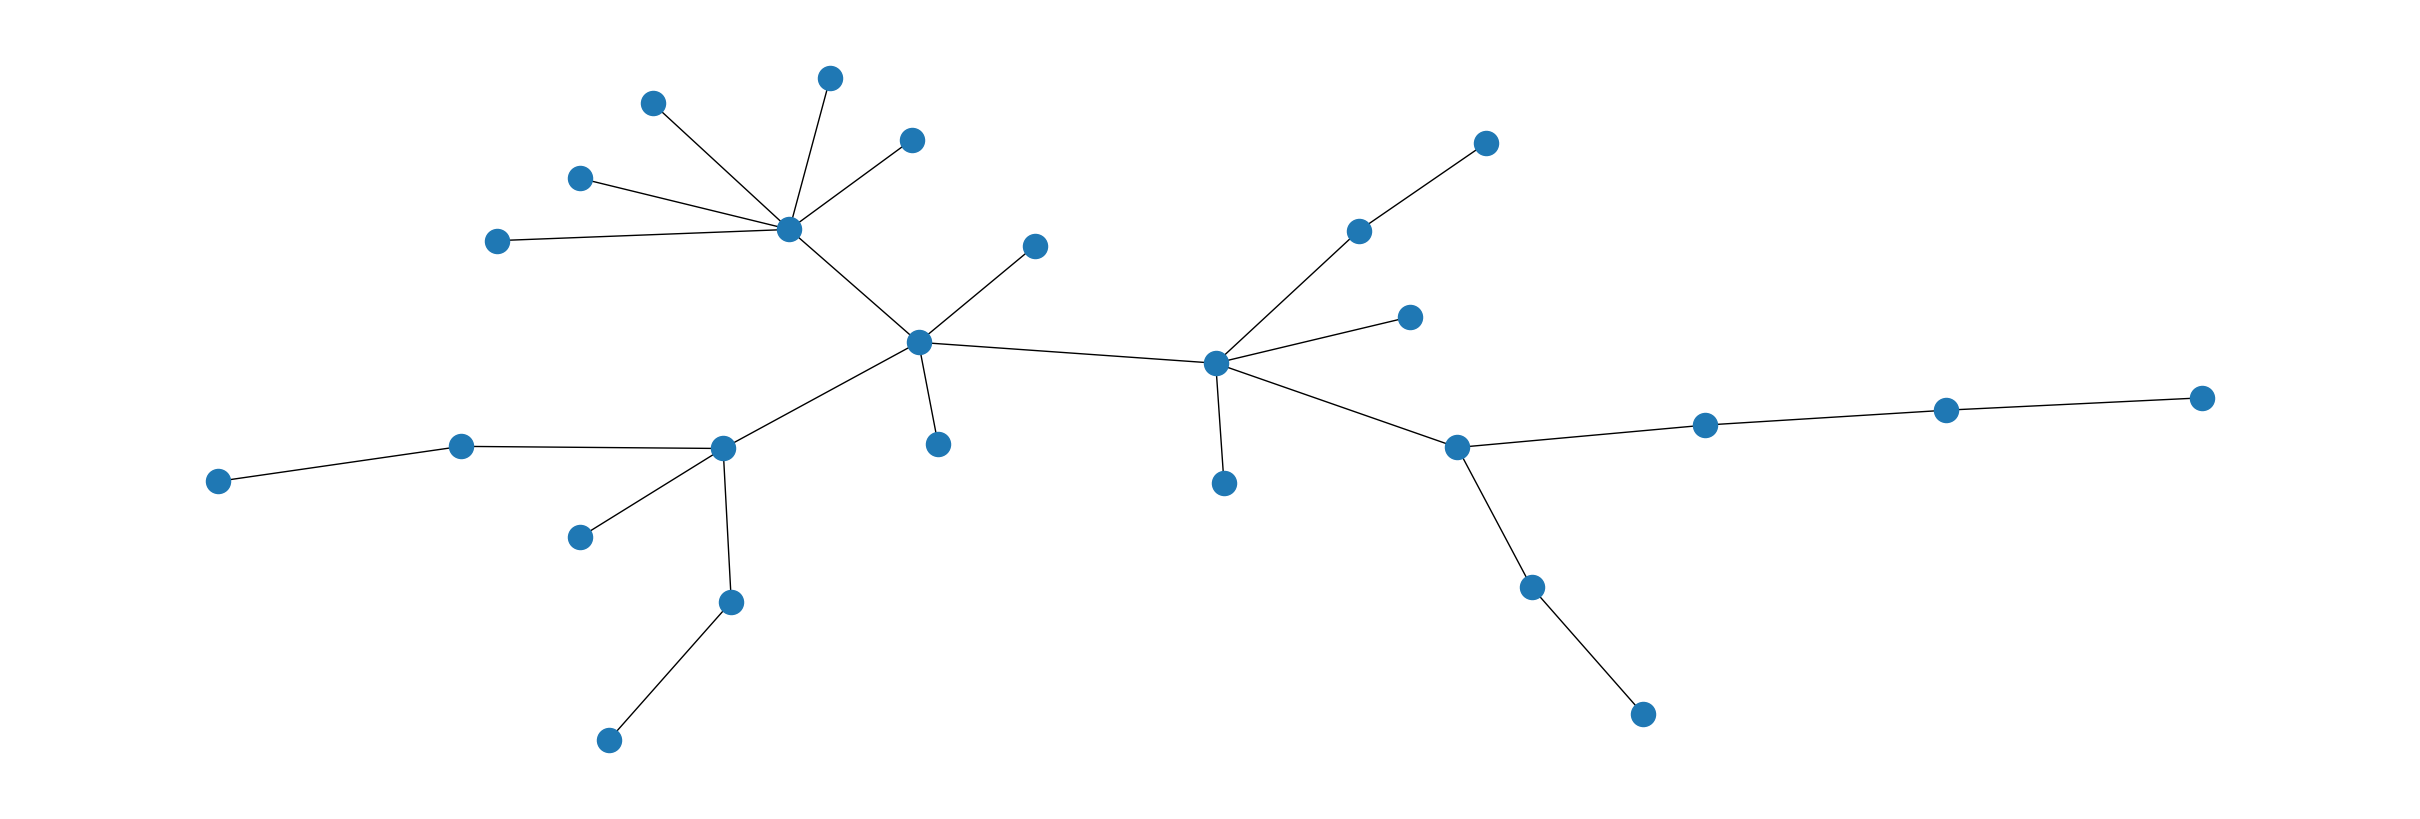

In [91]:
figure = plt.figure(figsize=(24, 8))
nx.draw_kamada_kawai(distance_2011_till_2020_graph_filtered, with_labels=False)

In [92]:
degree_centrality = nx.degree_centrality(distance_2011_till_2020_graph_filtered)
closeness_centrality = nx.closeness_centrality(distance_2011_till_2020_graph_filtered)
betweenness_centrality = nx.betweenness_centrality(distance_2011_till_2020_graph_filtered)
eigenvector_centrality=nx.eigenvector_centrality_numpy(distance_2011_till_2020_graph_filtered)

In [93]:
keys = []
values = []

for key, value in degree_centrality.items():
    keys.append(key)
    values.append(value)

dc_data = pd.DataFrame({'stocks': keys, 'degree_centrality': values}).sort_values('degree_centrality', ascending=False)
px.bar(data_frame=dc_data, x='stocks', y='degree_centrality', template='plotly_dark')

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'hovertemplate': 'stocks=%{x}<br>degree_centrality=%{y}<extra></extra>',
              'legendgroup': '',
              'marker': {'color': '#636efa', 'pattern': {'shape': ''}},
              'name': '',
              'orientation': 'v',
              'showlegend': False,
              'textposition': 'auto',
              'type': 'bar',
              'x': array(['KOF', 'GFNORTEO.MX', 'AMX', 'CEMEXCPO.MX', 'GFINBURO.MX',
                          'GCARSOA1.MX', 'GMEXICOB.MX', 'GAP', 'BIMBOA.MX', 'GAPB.MX',
                          'AZTECACPO.MX', 'FEMSAUBD.MX', 'WALMEX.MX', 'AC.MX', 'BOLSAA.MX',
                          'ASUR', 'PE&OLES.MX', 'PINFRA.MX', 'LAB', 'TLEVISACPO.MX', 'ASURB.MX',
                          'LIVEPOLC-1.MX', 'ALSEA.MX', 'LABB.MX', 'GRUMAB.MX', 'ICHB.MX'],
                         dtype=object),
              'xaxis': 'x',
              'y': {'bdata': ('uB6F61G4zj+amZmZmZnJP5qZmZmZmc' ... 'fheqQ/exSuR+F6pD97FK5H4XqkPw=='),
                    'dtype': 'f8'},
              'yaxis': 'y'}],
    'layout': {'barmode': 'relative',
               'legend': {'tracegroupgap': 0},
               'margin': {'t': 60},
               'template': '...',
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': 'stocks'}},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': 'degree_centrality'}}}
})

**Degree centrality** is the simplest centrality measure. It
defines the relative significance of a stock in terms of the
**number of edges incident upon it.** The stocks with the high
scores will influence the behavior of many other
stocks which are directly connected to it.

Based on this
measure, **HON has the highest number of edges with other
stocks and hence the highest degree centrality.**

In [94]:
keys = []
values = []

for key, value in closeness_centrality.items():
    keys.append(key)
    values.append(value)

cc_data = pd.DataFrame({'stocks': keys, 'closeness_centrality': values}).sort_values('closeness_centrality',
                                                                                       ascending=False)
px.bar(data_frame=cc_data, x='stocks', y='closeness_centrality', template='plotly_dark')

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'hovertemplate': 'stocks=%{x}<br>closeness_centrality=%{y}<extra></extra>',
              'legendgroup': '',
              'marker': {'color': '#636efa', 'pattern': {'shape': ''}},
              'name': '',
              'orientation': 'v',
              'showlegend': False,
              'textposition': 'auto',
              'type': 'bar',
              'x': array(['AMX', 'GFNORTEO.MX', 'KOF', 'CEMEXCPO.MX', 'GFINBURO.MX', 'BOLSAA.MX',
                          'ASUR', 'GAPB.MX', 'ALSEA.MX', 'WALMEX.MX', 'GMEXICOB.MX', 'GAP',
                          'FEMSAUBD.MX', 'GCARSOA1.MX', 'LABB.MX', 'AC.MX', 'LIVEPOLC-1.MX',
                          'PINFRA.MX', 'TLEVISACPO.MX', 'AZTECACPO.MX', 'ASURB.MX', 'BIMBOA.MX',
                          'LAB', 'PE&OLES.MX', 'ICHB.MX', 'GRUMAB.MX'], dtype=object),
              'xaxis': 'x',
              'y': {'bdata': ('H8F9BPcR3D/8FJcMwTraPyDRCpsDid' ... 'u1Wcs/oVSYeD9yyj9bhg7Y7bHGPw=='),
                    'dtype': 'f8'},
              'yaxis': 'y'}],
    'layout': {'barmode': 'relative',
               'legend': {'tracegroupgap': 0},
               'margin': {'t': 60},
               'template': '...',
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': 'stocks'}},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': 'closeness_centrality'}}}
})

**Closeness centrality** also involves the shortest path
between all possible pairs of stocks on a network.

It is
defined as the average number of shortest paths between a
stock and all other stocks reachable from it.

In [95]:
keys = []
values = []

for key, value in betweenness_centrality.items():
    keys.append(key)
    values.append(value)

bc_data = pd.DataFrame({'stocks': keys, 'betweenness_centrality': values}).sort_values('betweenness_centrality',
                                                                                       ascending=False)
px.bar(data_frame=bc_data, x='stocks', y='betweenness_centrality', template='plotly_dark')

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'hovertemplate': 'stocks=%{x}<br>betweenness_centrality=%{y}<extra></extra>',
              'legendgroup': '',
              'marker': {'color': '#636efa', 'pattern': {'shape': ''}},
              'name': '',
              'orientation': 'v',
              'showlegend': False,
              'textposition': 'auto',
              'type': 'bar',
              'x': array(['AMX', 'GFNORTEO.MX', 'KOF', 'CEMEXCPO.MX', 'GFINBURO.MX',
                          'GCARSOA1.MX', 'GMEXICOB.MX', 'GAP', 'BIMBOA.MX', 'GAPB.MX',
                          'AZTECACPO.MX', 'FEMSAUBD.MX', 'WALMEX.MX', 'AC.MX', 'BOLSAA.MX',
                          'ASUR', 'PE&OLES.MX', 'PINFRA.MX', 'LAB', 'TLEVISACPO.MX', 'ASURB.MX',
                          'LIVEPOLC-1.MX', 'ALSEA.MX', 'LABB.MX', 'GRUMAB.MX', 'ICHB.MX'],
                         dtype=object),
              'xaxis': 'x',
              'y': {'bdata': ('7+7u7u7u5j8YS36x5BfjP3h3d3d3d9' ... 'AAAAAAAAAAAAAAAAAAAAAAAAAAAA=='),
                    'dtype': 'f8'},
              'yaxis': 'y'}],
    'layout': {'barmode': 'relative',
               'legend': {'tracegroupgap': 0},
               'margin': {'t': 60},
               'template': '...',
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': 'stocks'}},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': 'betweenness_centrality'}}}
})

**Betweenness centrality** is the sum of the fraction of all possible shortest paths between any stocks that pass through a stock. It is used to **quantify the control of a stock on information flow in the network.**

So, the stock with the highest score is considered a significant stock in terms of its role in coordinating the information among stocks.

## **Selecting Stocks based on Network Topological Parameters**

In [96]:
# we already computed degree centrality above

# we already computed betweenness centrality above

# distance on degree criterion
distance_degree_criteria = {}
node_with_largest_degree_centrality = max(dict(degree_centrality), key=dict(degree_centrality).get)
for node in distance_2011_till_2020_graph_filtered.nodes():
    distance_degree_criteria[node] = nx.shortest_path_length(distance_2011_till_2020_graph_filtered, node,
                                                             node_with_largest_degree_centrality)

# distance on correlation criterion
distance_correlation_criteria = {}
sum_correlation = {}

for node in distance_2011_till_2020_graph_filtered.nodes():
    neighbors = nx.neighbors(distance_2011_till_2020_graph_filtered, node)
    sum_correlation[node] = sum(return_correlation_2011_till_2020[node][neighbor] for neighbor in neighbors)

node_with_highest_correlation = max(sum_correlation, key=sum_correlation.get)

for node in distance_2011_till_2020_graph_filtered.nodes():
    distance_correlation_criteria[node] = nx.shortest_path_length(distance_2011_till_2020_graph_filtered, node,
                                                             node_with_highest_correlation)

# distance on distance criterion
distance_distance_criteria = {}
mean_distance = {}

for node in distance_2011_till_2020_graph_filtered.nodes():
    nodes = list(distance_2011_till_2020_graph_filtered.nodes())
    nodes.remove(node)
    distance_distance = [nx.shortest_path_length(distance_2011_till_2020_graph_filtered, node, ns) for ns in nodes]
    mean_distance[node] = np.mean(distance_distance)

node_with_minimum_mean_distance = min(mean_distance, key=mean_distance.get)

for node in distance_2011_till_2020_graph_filtered.nodes():
    distance_distance_criteria[node] = nx.shortest_path_length(distance_2011_till_2020_graph_filtered, node,
                                                             node_with_minimum_mean_distance)

**Distance refers to the smallest length from a node to the central node of the network**.

Here,
three types of definitions of central node are introduced to reduce the error caused by a single
method.

Therefore three types of distances are described here.

**1. Distance on degree criterion** (Ddegree), the central node is the one that has the largest degree.

**2. Distance on correlation criterion** (Dcorrelation), the central node is the one with the highest value of the sum of correlation coefficients with its neighbors.

**3. Distance on distance criterion** (Ddistance), the central node is the one that produces the lowest value for the mean distance.

In [97]:
node_stats = pd.DataFrame.from_dict(dict(degree_centrality), orient='index')
node_stats.columns = ['degree_centrality']
node_stats['betweenness_centrality'] = betweenness_centrality.values()

node_stats['average_centrality'] = 0.5 * (node_stats['degree_centrality'] + node_stats['betweenness_centrality'])

node_stats['distance_degree_criteria'] = distance_degree_criteria.values()
node_stats['distance_correlation_criteria'] = distance_correlation_criteria.values()
node_stats['distance_distance_criteria'] = distance_distance_criteria.values()
node_stats['average_distance'] = (node_stats['distance_degree_criteria'] + node_stats['distance_correlation_criteria'] +
                                  node_stats['distance_distance_criteria']) / 3



In [98]:
node_stats.head()

,degree_centrality,betweenness_centrality,average_centrality,distance_degree_criteria,distance_correlation_criteria,distance_distance_criteria,average_distance
GFINBURO.MX,0.12,0.353333,0.236667,3,3,2,2.666667
GCARSOA1.MX,0.08,0.153333,0.116667,4,4,3,3.666667
BOLSAA.MX,0.04,0.000000,0.020000,2,2,1,1.666667
FEMSAUBD.MX,0.04,0.000000,0.020000,1,1,2,1.333333
WALMEX.MX,0.04,0.000000,0.020000,3,3,2,2.666667


We use the parameters defined above to select the portfolios.

**The nodes with the largest 10% of degree or betweenness centrality are chosen to be in the central portfolio.**

**The nodes whose degree equals to 1 or betweenness centrality equals to 0 are chosen to be in the peripheral portfolio.**


Similarly, we define the node's ranking in the top 10% of distance as the stocks of the peripheral portfolios, and the bottom 10% as the stocks of the central portfolios.

The central portfolios and peripheral portfolios represent two opposite sides of correlation and agglomeration. Generally speaking, central stocks play a vital role in the market and impose a strong influence on other stocks. On the other hand, the correlations between peripheral stocks are weak and contain much more noise than those of the central stocks.

In [105]:
central_stocks = node_stats.sort_values('average_centrality', ascending=False).head(5)
central_portfolio = [stock for stock in central_stocks.index.values]

In [106]:
peripheral_stocks = node_stats.sort_values('average_distance', ascending=False).head(5)
peripheral_portfolio = [stock for stock in peripheral_stocks.index.values]

In [107]:
central_stocks

,degree_centrality,betweenness_centrality,average_centrality,distance_degree_criteria,distance_correlation_criteria,distance_distance_criteria,average_distance
AMX,0.20,0.716667,0.458333,1,1,0,0.666667
GFNORTEO.MX,0.20,0.596667,0.398333,2,2,1,1.666667
KOF,0.24,0.366667,0.303333,0,0,1,0.333333
CEMEXCPO.MX,0.16,0.360000,0.260000,2,2,1,1.666667
GFINBURO.MX,0.12,0.353333,0.236667,3,3,2,2.666667


In [108]:
peripheral_stocks

,degree_centrality,betweenness_centrality,average_centrality,distance_degree_criteria,distance_correlation_criteria,distance_distance_criteria,average_distance
GRUMAB.MX,0.04,0.00,0.02,6,6,5,5.666667
BIMBOA.MX,0.08,0.08,0.08,5,5,4,4.666667
ICHB.MX,0.04,0.00,0.02,5,5,4,4.666667
PE&OLES.MX,0.04,0.00,0.02,4,4,3,3.666667
ASURB.MX,0.04,0.00,0.02,4,4,3,3.666667


### **Selecting the top 5 stocks for both Central Stocks and Peripheral Stocks**

In [109]:
color = []

for node in distance_2011_till_2020_graph_filtered:
    if node in central_portfolio:
        color.append('red')

    elif node in peripheral_portfolio:
        color.append('green')

    else:
        color.append('blue')

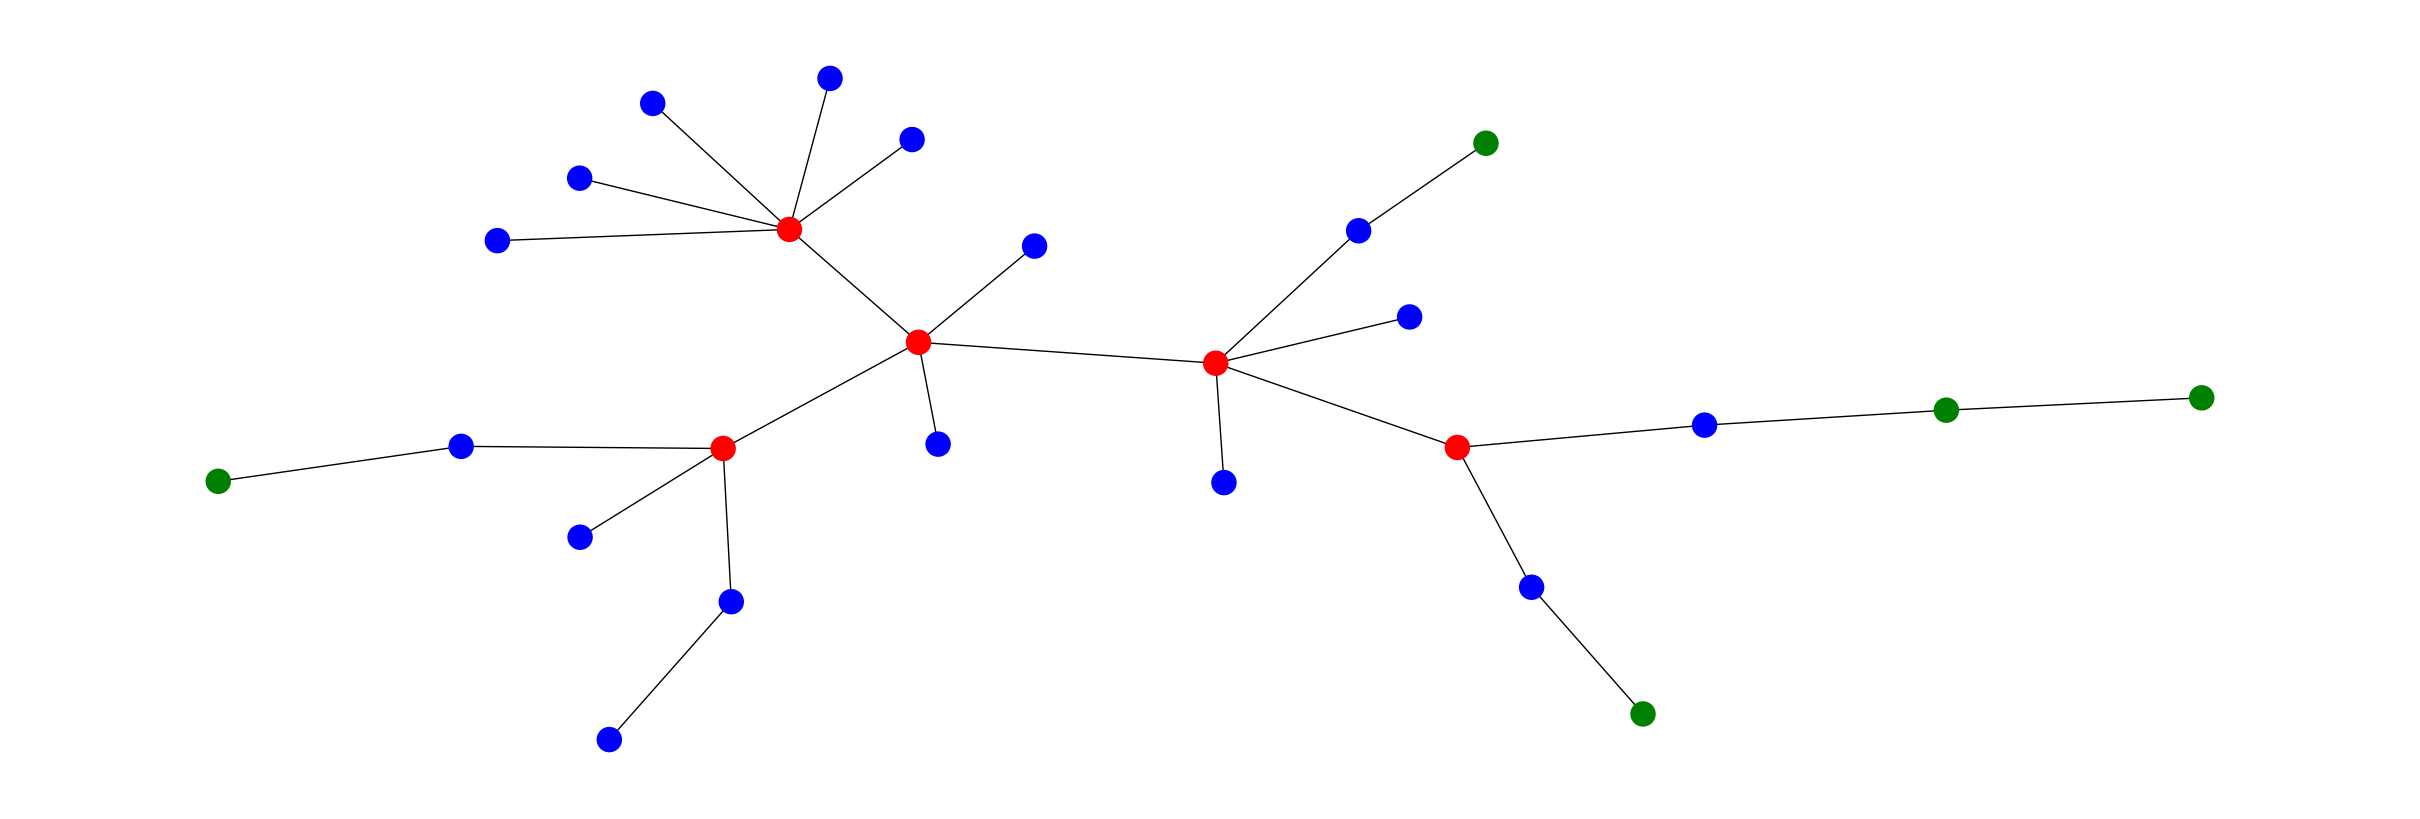

In [110]:
figure = plt.figure(figsize=(24, 8))
nx.draw_kamada_kawai(distance_2011_till_2020_graph_filtered, with_labels=False, node_color=color)

Here, **the red stocks are the central portfolio stocks, and the green ones are the peripheral portfolio stocks.**

## **Performance Evalutation**

Here we evaluate the performance of the stocks by comparing the performance of the Central Portfolio, Peripheral and S&P 500 Stocks in 2021, and **finding out which portfolio performs the best.**

In [147]:
# collecting data for all S&P 500 components for the year 2021
stock_data_2021 = yf.download(tickers, start='2021-01-01', end='2021-12-31', group_by='ticker', auto_adjust=True)

# Filter the dataset to just close price
price_data_2021 = stock_data_2021.xs(key="Close", axis=1, level="Price")

$COMPARC.MX: possibly delisted; no price data found  (1d 2021-01-01 -> 2021-12-31)
[**                     4%                       ]  5 of 118 completed$ALPEK.MX: possibly delisted; no timezone found
$LALA.MX: possibly delisted; no timezone found
[**                     5%                       ]  6 of 118 completed$GMEXICO.MX: possibly delisted; no timezone found
[***                    6%                       ]  7 of 118 completed$AMX.MX: possibly delisted; no timezone found
[***                    6%                       ]  7 of 118 completed$ALFAA.MX: possibly delisted; no timezone found
[****                   8%                       ]  9 of 118 completed$ASURB: possibly delisted; no timezone found
[****                   8%                       ]  10 of 118 completed$ALFAA: possibly delisted; no timezone found
[****                   8%                       ]  10 of 118 completed$IENOVA: possibly delisted; no timezone found
[*****                 10%                       ]

In [148]:
price_data_2021.head()

Ticker,COMPARC.MX,BOLSAA.MX,GFINBURO.MX,ALFA.MX,GCARSOA1.MX,ALPEK.MX,LALA.MX,GMEXICO.MX,AMX.MX,ALFAA.MX,...,LABB.MX,ICHB.MX,GMEXICOB.MX,GFNORTE.MX,GFNORTEO,KOF.MX,IENOVA.MX,ELEKTRA.MX,GFREGIOO.MX,AZTECACPO.MX
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,NaN,34.641117,19.898563,75.963402,61.199783,NaN,NaN,NaN,NaN,NaN,...,14.676689,94.739998,67.858749,NaN,NaN,NaN,NaN,NaN,NaN,0.433
2021-01-05,NaN,34.677113,19.334675,76.806297,61.789780,NaN,NaN,NaN,NaN,NaN,...,14.668854,94.410004,69.503403,NaN,NaN,NaN,NaN,NaN,NaN,0.433
2021-01-06,NaN,34.986732,19.296446,76.155502,62.623257,NaN,NaN,NaN,NaN,NaN,...,15.389763,94.500000,70.023567,NaN,NaN,NaN,NaN,NaN,NaN,0.447
2021-01-07,NaN,35.339554,19.879450,79.395302,63.306896,NaN,NaN,NaN,NaN,NaN,...,15.522972,96.959999,70.842056,NaN,NaN,NaN,NaN,NaN,NaN,0.455
2021-01-08,NaN,35.857979,19.697859,80.672096,64.898926,NaN,NaN,NaN,NaN,NaN,...,15.358420,107.849998,74.376137,NaN,NaN,NaN,NaN,NaN,NaN,0.457


In [149]:
snp_500_2021 = yf.download('^MXX', start='2021-01-01', end='2021-12-31')['Close']
snp_500_2021 = snp_500_2021.rename(columns={'^MXX': 'sp500'})

[*********************100%***********************]  1 of 1 completed


In [150]:
price_data_2021.head()

Ticker,COMPARC.MX,BOLSAA.MX,GFINBURO.MX,ALFA.MX,GCARSOA1.MX,ALPEK.MX,LALA.MX,GMEXICO.MX,AMX.MX,ALFAA.MX,...,LABB.MX,ICHB.MX,GMEXICOB.MX,GFNORTE.MX,GFNORTEO,KOF.MX,IENOVA.MX,ELEKTRA.MX,GFREGIOO.MX,AZTECACPO.MX
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,NaN,34.641117,19.898563,75.963402,61.199783,NaN,NaN,NaN,NaN,NaN,...,14.676689,94.739998,67.858749,NaN,NaN,NaN,NaN,NaN,NaN,0.433
2021-01-05,NaN,34.677113,19.334675,76.806297,61.789780,NaN,NaN,NaN,NaN,NaN,...,14.668854,94.410004,69.503403,NaN,NaN,NaN,NaN,NaN,NaN,0.433
2021-01-06,NaN,34.986732,19.296446,76.155502,62.623257,NaN,NaN,NaN,NaN,NaN,...,15.389763,94.500000,70.023567,NaN,NaN,NaN,NaN,NaN,NaN,0.447
2021-01-07,NaN,35.339554,19.879450,79.395302,63.306896,NaN,NaN,NaN,NaN,NaN,...,15.522972,96.959999,70.842056,NaN,NaN,NaN,NaN,NaN,NaN,0.455
2021-01-08,NaN,35.857979,19.697859,80.672096,64.898926,NaN,NaN,NaN,NaN,NaN,...,15.358420,107.849998,74.376137,NaN,NaN,NaN,NaN,NaN,NaN,0.457


In [162]:
# Removing NA values:
price_data_2021 = price_data_2021.dropna(axis=1, how='all')
price_data_2021_clean = price_data_2021.drop([ 'ICA.MX', 'ALFA', 'ALFA.MX', 'ALPEKA.MX'], axis=1) # dropping na values columnwise


# Reindexamos para tener las mismas fechas
indice = snp_500_2021.index.union(price_data_2021_clean.index)
price_data_2021_clean = price_data_2021_clean.reindex(indice)
snp_500_2021 = snp_500_2021.reindex(indice)

# Hacemos interpolacion para rellenar las fechas faltantes
price_data_2021_clean = price_data_2021_clean.interpolate(method='time', limit_direction='both')
snp_500_2021 = snp_500_2021.interpolate(method='time', limit_direction='both')

In [163]:
price_data_2021_clean.head()

Ticker,BOLSAA.MX,GFINBURO.MX,GCARSOA1.MX,GAPB.MX,FEMSAUBD.MX,AC.MX,KOF,WALMEX.MX,BIMBOA.MX,CEMEXCPO.MX,...,LAB,GAP,AMX,GFNORTEO.MX,ALSEA.MX,GRUMAB.MX,LABB.MX,ICHB.MX,GMEXICOB.MX,AZTECACPO.MX
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,34.641117,19.898563,61.199783,169.628525,122.279312,75.179169,37.259308,49.695499,38.755104,10.223190,...,6.17,15.738354,12.800249,69.812248,25.151535,216.323776,14.676689,94.739998,67.858749,0.433
2021-01-05,34.677113,19.334675,61.789780,169.284851,121.480133,76.828293,37.544861,50.338188,38.935993,10.488855,...,6.38,16.172352,12.913065,68.640457,25.027353,213.473129,14.668854,94.410004,69.503403,0.433
2021-01-06,34.986732,19.296446,62.623257,178.689148,120.876686,77.460724,38.221996,51.944912,38.818420,11.364566,...,6.21,17.531647,13.077950,69.680664,25.371239,211.948547,15.389763,94.500000,70.023567,0.447
2021-01-07,35.339554,19.879450,63.306896,183.617783,121.056107,80.334671,38.001724,50.989552,39.361084,11.462960,...,6.19,17.605343,12.887032,73.465477,25.533630,213.219025,15.522972,96.959999,70.842056,0.455
2021-01-08,35.857979,19.697859,64.898926,180.438782,122.507629,79.926399,38.270950,52.761295,39.216373,11.384245,...,6.32,17.539831,12.982490,73.709854,25.657812,210.741547,15.358420,107.849998,74.376137,0.457


In [164]:
amount = 100000

central_portfolio_value = pd.DataFrame()
for stock in central_portfolio:
    central_portfolio_value[stock] = price_data_2021_clean[stock]

portfolio_unit = central_portfolio_value.sum(axis=1).iloc[0]
share = amount / portfolio_unit
central_portfolio_value = central_portfolio_value.sum(axis=1) * share

peripheral_portfolio_value = pd.DataFrame()
for stock in peripheral_portfolio:
    peripheral_portfolio_value[stock] = price_data_2021_clean[stock]

portfolio_unit = peripheral_portfolio_value.sum(axis=1).iloc[0]
share = amount / portfolio_unit
peripheral_portfolio_value = peripheral_portfolio_value.sum(axis=1) * share

In [165]:
snp_500_2021_value = snp_500_2021 * (amount / snp_500_2021.iloc[0])

In [166]:
all_portfolios = snp_500_2021_value
all_portfolios['central_portfolio'] = central_portfolio_value.values
all_portfolios['peripheral_portfolio'] = peripheral_portfolio_value.values

In [ ]:
# all_portfolios = pd.concat([snp_500_2021_value, central_portfolio_value, peripheral_portfolio_value], axis=1)
# all_portfolios.columns = ['snp500', 'central_portfolio', 'peripheral_portfolio']

: 

In [167]:
all_portfolios.head()

Ticker,sp500,central_portfolio,peripheral_portfolio
Date,,,
2021-01-04,100000.000000,100000.000000,100000.000000
2021-01-05,100458.853083,99285.538829,99791.894602
2021-01-06,101977.854185,101098.756288,101062.538267
2021-01-07,103323.401464,103802.219265,102026.043161
2021-01-08,104532.807152,104034.732504,100798.957212


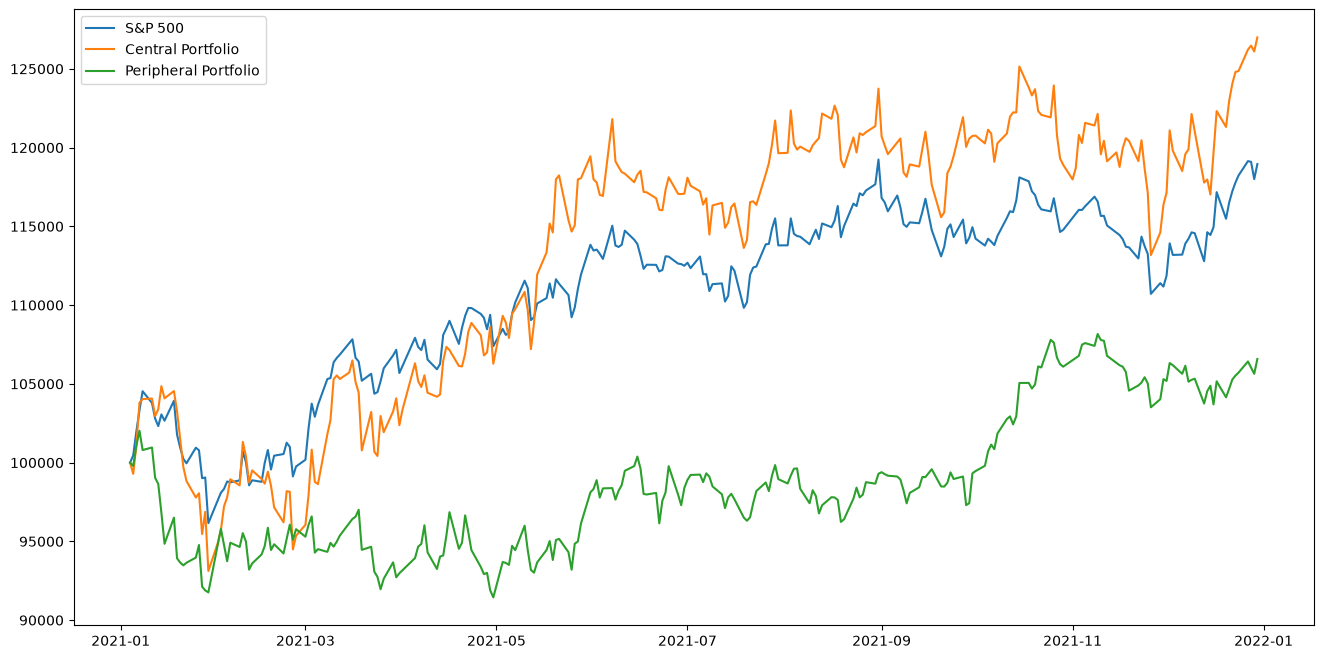

In [168]:
figure, ax = plt.subplots(figsize=(16, 8))
snp_500_line = ax.plot(all_portfolios['sp500'], label='S&P 500')
central_portfolio_line = ax.plot(all_portfolios['central_portfolio'], label= 'Central Portfolio')
peripheral_portfolio_line = ax.plot(all_portfolios['peripheral_portfolio'], label= 'Peripheral Portfolio')
ax.legend(loc='upper left')
plt.show()

As seen from the above plot, it is clear that **the Central Portfolio stocks perform better and the Peripheral Portfolio stocks perform poorer in comparison to the S&P 500 stocks in 2021.**

   Both the portfolios have their own features under different market conditions.
   
   Generally, **in stable market conditions Central Portfolio Stocks will perform better whereas Peripheral Portfolio Stocks will perform better in crisis market conditions**. This is due to peripheral portfolio stocks are kind of having a weak correlation so they will not be impacted by all other stocks that were present in our network.
   
   We can rebalance our stocks portfolio by using the network analysis.